In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
n = 3500

data = {
    "customer_id": range(1, n+1),

    "age": np.random.randint(21,65,n),

    "annual_income": np.random.randint(20000,200000,n),

    "credit_score": np.random.randint(300,850,n),

    "loan_amount": np.random.randint(5000,500000,n),

    "loan_term_years": np.random.choice([1,3,5,10,15,20],n),

    "debt_to_income_ratio": np.round(np.random.uniform(0.1,0.8,n),2),

    "late_payments": np.random.randint(0,10,n),

    "employment_type": np.random.choice(
        ["Salaried","Self-Employed","Business","Unemployed"], n),

    "education": np.random.choice(
        ["High School","Graduate","Postgraduate","PhD"], n),

    "loan_purpose": np.random.choice(
        ["Home","Car","Education","Business","Personal"], n),

    "default": np.random.choice([0,1], n, p=[0.8,0.2])
}

df = pd.DataFrame(data)

df.to_csv("loan_data.csv", index=False)

df.head()

,customer_id,age,annual_income,credit_score,loan_amount,loan_term_years,debt_to_income_ratio,late_payments,employment_type,education,loan_purpose,default
0,1,59,149936,528,462141,15,0.12,6,Salaried,High School,Personal,0
1,2,49,166664,525,75825,1,0.28,2,Self-Employed,Postgraduate,Personal,0
2,3,35,173245,734,56574,15,0.30,3,Business,Graduate,Education,0
3,4,63,184276,701,352692,10,0.74,7,Salaried,High School,Personal,0
4,5,28,186668,387,417028,3,0.55,3,Business,Graduate,Personal,0


In [3]:
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           3500 non-null   int64  
 1   age                   3500 non-null   int32  
 2   annual_income         3500 non-null   int32  
 3   credit_score          3500 non-null   int32  
 4   loan_amount           3500 non-null   int32  
 5   loan_term_years       3500 non-null   int64  
 6   debt_to_income_ratio  3500 non-null   float64
 7   late_payments         3500 non-null   int32  
 8   employment_type       3500 non-null   str    
 9   education             3500 non-null   str    
 10  loan_purpose          3500 non-null   str    
 11  default               3500 non-null   int64  
dtypes: float64(1), int32(5), int64(3), str(3)
memory usage: 259.9 KB


In [4]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_18540\4024316392.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [5]:
df.describe()
df.skew(numeric_only=True)
df['default'].value_counts(normalize=True)*100

default
0    81.428571
1    18.571429
Name: proportion, dtype: float64

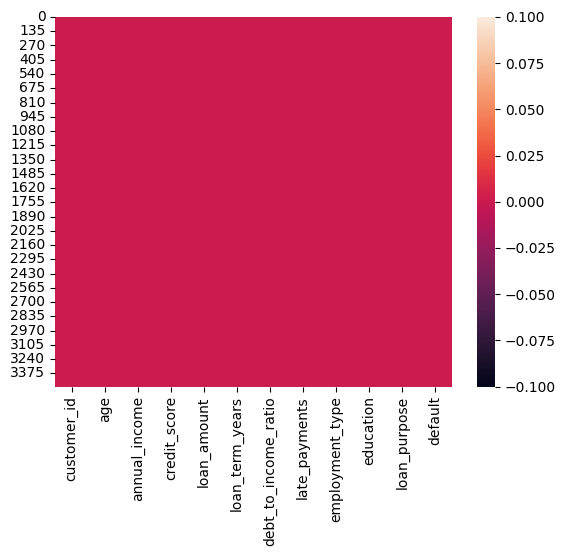

In [6]:
df.isnull().sum()
sns.heatmap(df.isnull())
plt.show()

In [7]:
df.fillna(df.median(numeric_only=True), inplace=True)

,customer_id,age,annual_income,credit_score,loan_amount,loan_term_years,debt_to_income_ratio,late_payments,employment_type,education,loan_purpose,default
0,1,59,149936,528,462141,15,0.12,6,Salaried,High School,Personal,0
1,2,49,166664,525,75825,1,0.28,2,Self-Employed,Postgraduate,Personal,0
2,3,35,173245,734,56574,15,0.30,3,Business,Graduate,Education,0
3,4,63,184276,701,352692,10,0.74,7,Salaried,High School,Personal,0
4,5,28,186668,387,417028,3,0.55,3,Business,Graduate,Personal,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3495,3496,47,164615,411,151444,20,0.43,6,Salaried,High School,Business,0
3496,3497,49,173857,520,262320,10,0.66,6,Salaried,PhD,Business,0
3497,3498,59,98353,603,22279,5,0.13,2,Salaried,Postgraduate,Home,0
3498,3499,59,182478,624,115401,5,0.21,1,Unemployed,Postgraduate,Education,1


In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

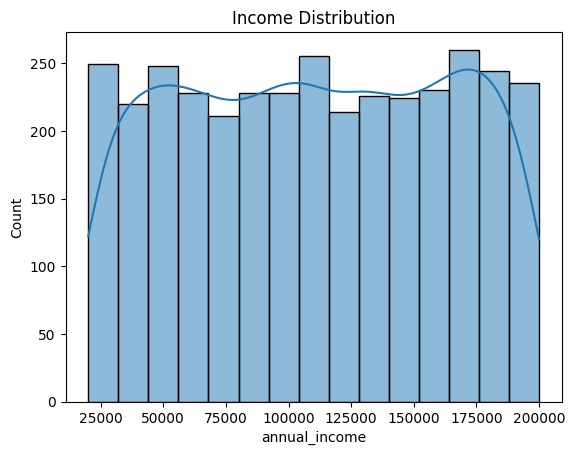

In [9]:
sns.histplot(df['annual_income'], kde=True)
plt.title("Income Distribution")
plt.show()

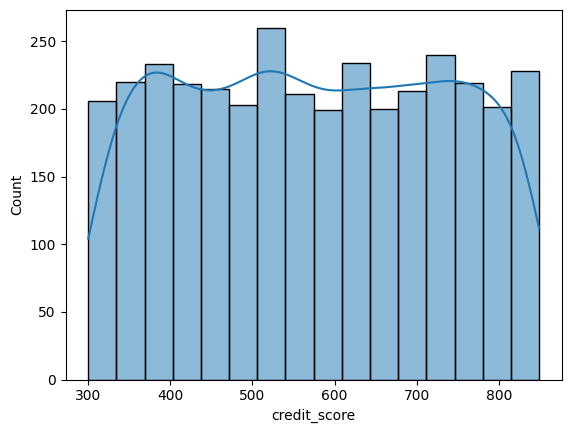

In [10]:
sns.histplot(df['credit_score'], kde=True)
plt.show()

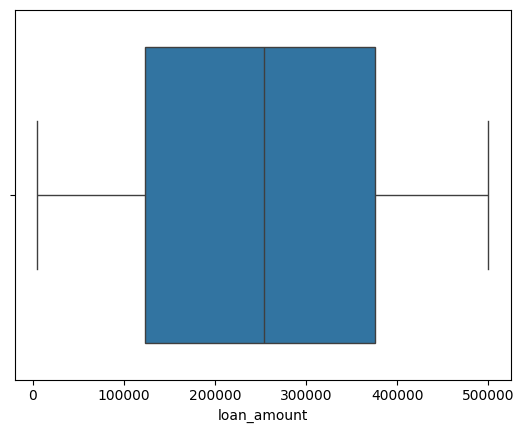

In [11]:
sns.boxplot(x=df['loan_amount'])
plt.show()

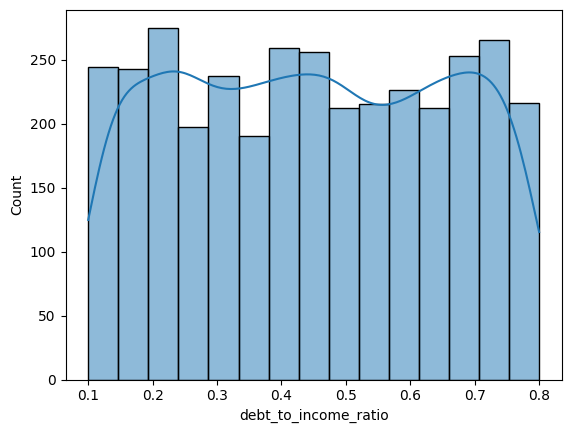

In [12]:
sns.histplot(df['debt_to_income_ratio'], kde=True)
plt.show()

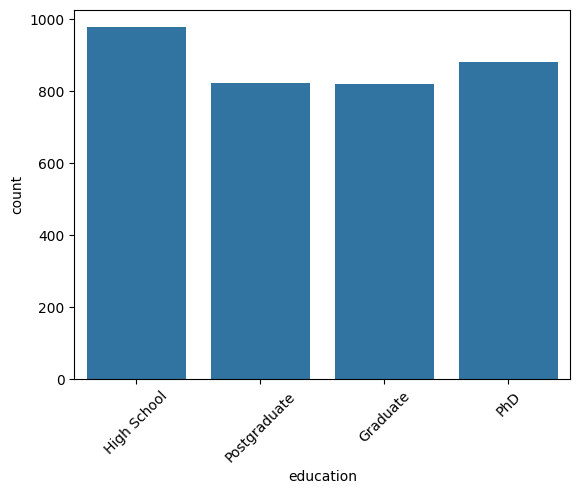

In [13]:
sns.countplot(x='education', data=df)
plt.xticks(rotation=45)
plt.show()

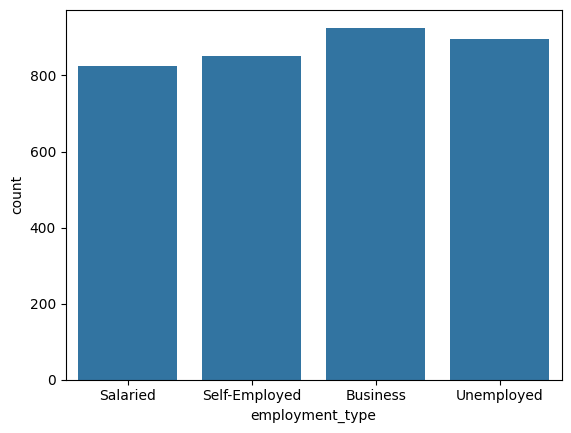

In [14]:
sns.countplot(x='employment_type', data=df)
plt.show()

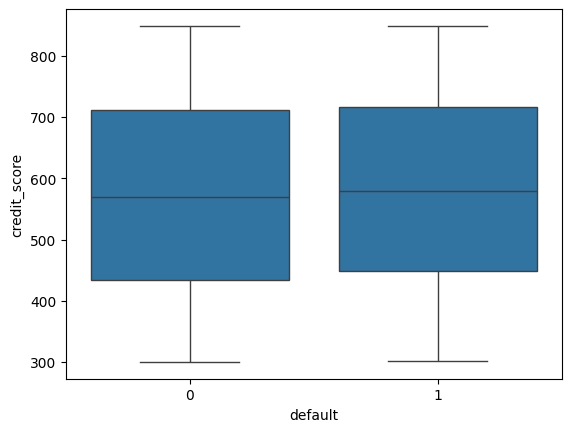

In [15]:
sns.boxplot(x='default', y='credit_score', data=df)
plt.show()

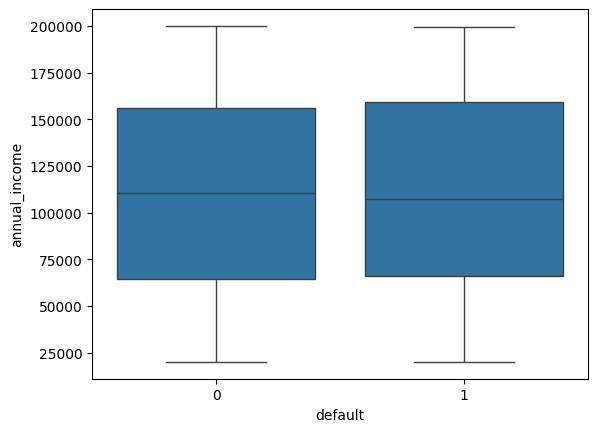

In [16]:
sns.boxplot(x='default', y='annual_income', data=df)
plt.show()

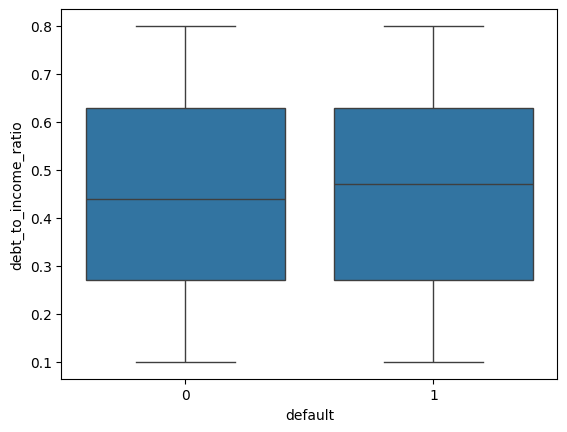

In [17]:
sns.boxplot(x='default', y='debt_to_income_ratio', data=df)
plt.show()

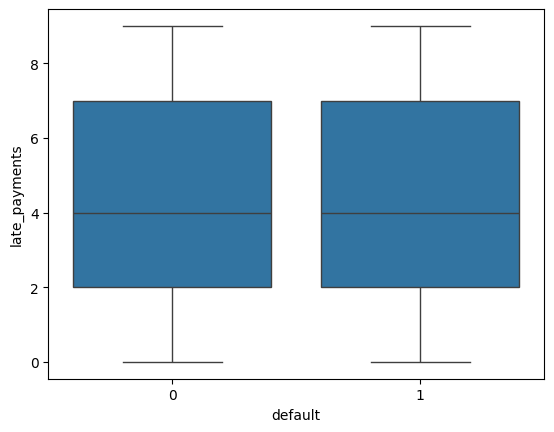

In [18]:
sns.boxplot(x='default', y='late_payments', data=df)
plt.show()

In [19]:
pd.crosstab(df['education'], df['default'], normalize='index')

default,0,1
education,,
Graduate,0.825822,0.174178
High School,0.818833,0.181167
PhD,0.813636,0.186364
Postgraduate,0.798054,0.201946


In [20]:
pd.crosstab(df['employment_type'], df['default'])

default,0,1
employment_type,,
Business,769,157
Salaried,657,168
Self-Employed,697,155
Unemployed,727,170


In [21]:
pd.crosstab(df['loan_purpose'], df['default'])

default,0,1
loan_purpose,,
Business,536,132
Car,563,130
Education,586,140
Home,558,109
Personal,607,139


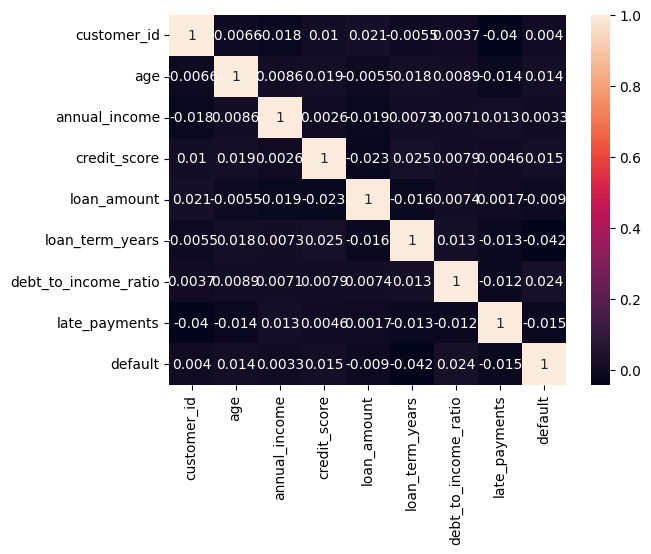

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

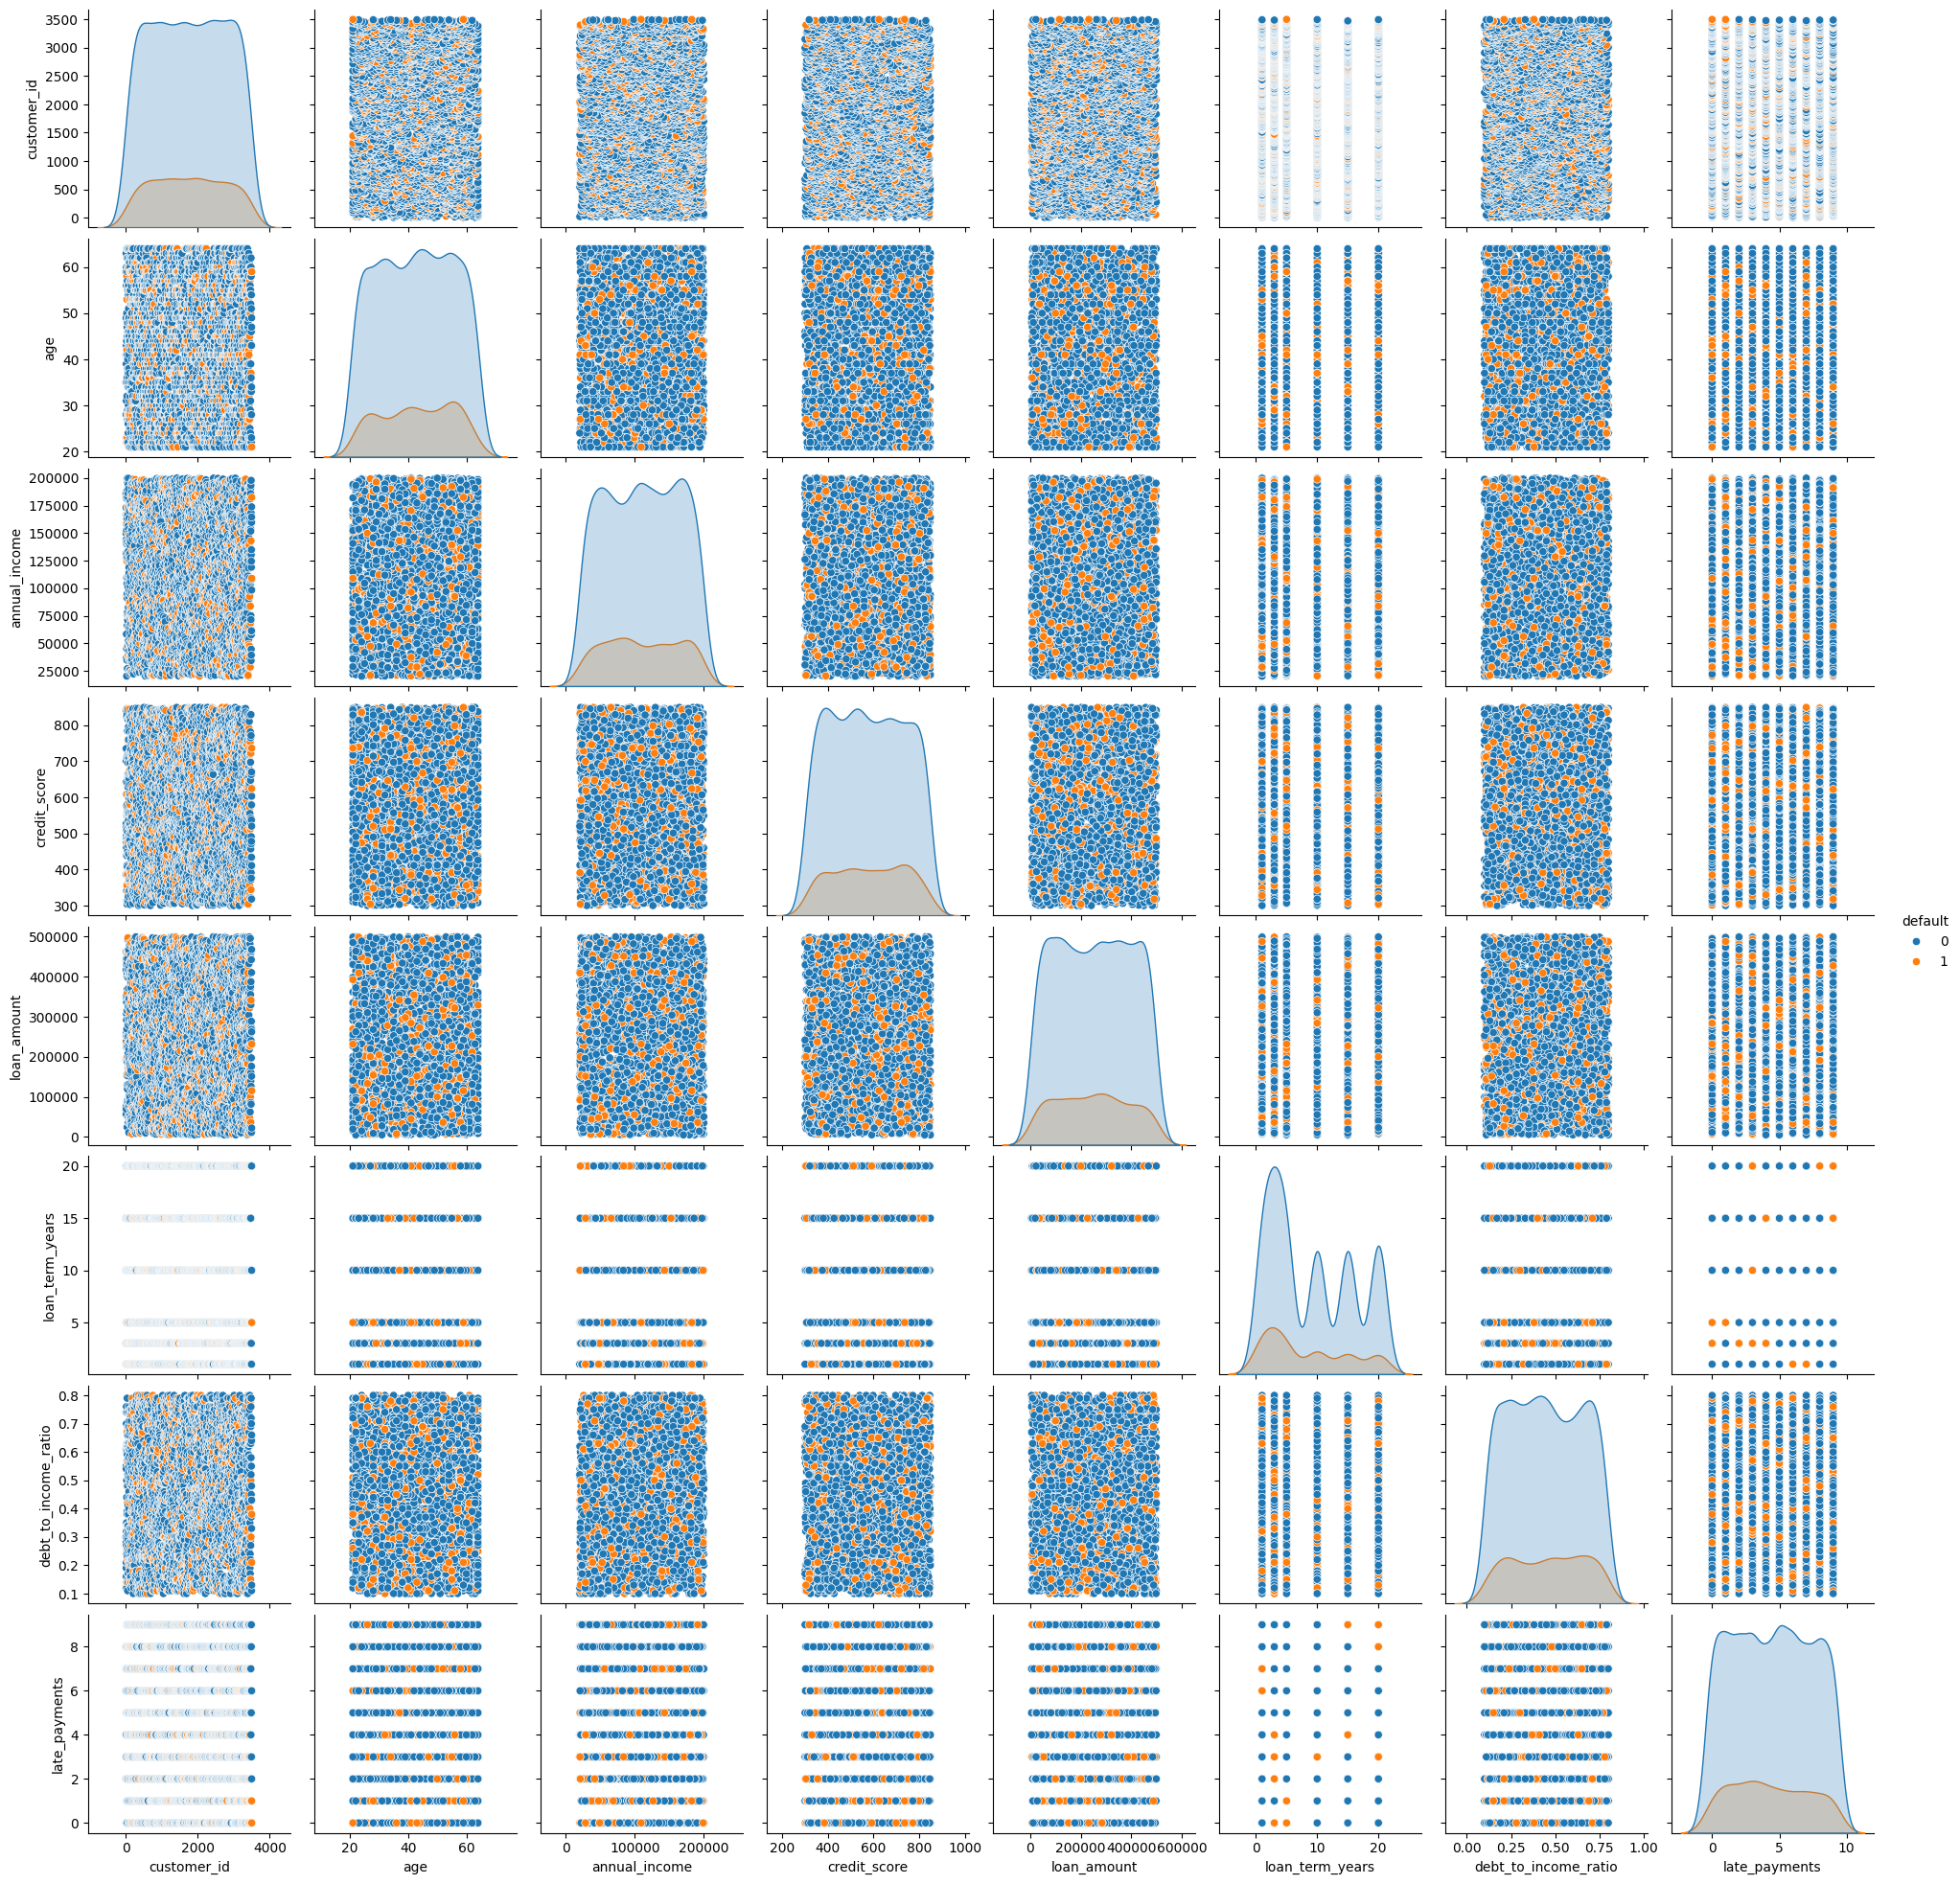

In [23]:
sns.pairplot(df, hue='default')

In [24]:
df.groupby('loan_purpose')['default'].mean()

loan_purpose
Business     0.197605
Car          0.187590
Education    0.192837
Home         0.163418
Personal     0.186327
Name: default, dtype: float64

In [25]:
pd.pivot_table(df,
               values='default',
               index='employment_type',
               columns='education')

education,Graduate,High School,PhD,Postgraduate
employment_type,,,,
Business,0.175214,0.175966,0.177686,0.147465
Salaried,0.157068,0.247788,0.180995,0.224599
Self-Employed,0.164894,0.173228,0.201970,0.188406
Unemployed,0.197115,0.136364,0.186916,0.251185


In [26]:
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1

In [27]:
outliers = df[(df['loan_amount'] > Q3+1.5*IQR)]

In [28]:
df['loan_amount'] = np.clip(df['loan_amount'],
                            df['loan_amount'].quantile(0.05),
                            df['loan_amount'].quantile(0.95))

In [29]:
df['loan_to_income_ratio'] = df['loan_amount'] / df['annual_income']

In [30]:
df['risk_score'] = (
    (850 - df['credit_score']) +
    df['debt_to_income_ratio']*100 +
    df['late_payments']*10
)

In [31]:
df['income_category'] = pd.qcut(
df['annual_income'],3,
labels=['Low','Medium','High'])

In [32]:
df['risk_segment'] = pd.qcut(
df['risk_score'],3,
labels=['Low Risk','Medium Risk','High Risk'])

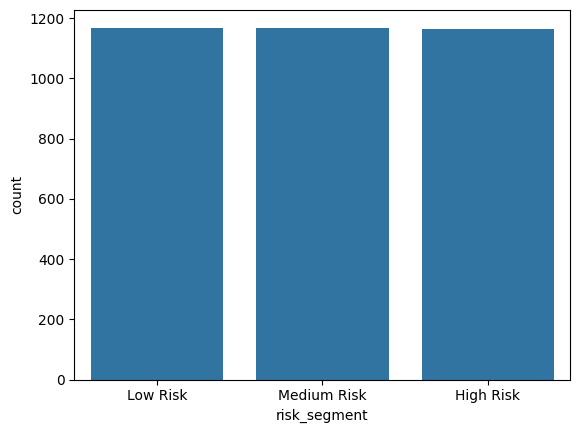

In [33]:
sns.countplot(x='risk_segment', data=df)
plt.show()

In [34]:
df.groupby('risk_segment')['default'].mean()

risk_segment
Low Risk       0.193328
Medium Risk    0.182519
High Risk      0.181271
Name: default, dtype: float64

In [35]:
df.corr(numeric_only=True)['default'].sort_values(ascending=False)

default                 1.000000
debt_to_income_ratio    0.024493
credit_score            0.015219
age                     0.014096
customer_id             0.003996
annual_income           0.003314
loan_to_income_ratio   -0.005862
loan_amount            -0.009724
risk_score             -0.014425
late_payments          -0.014787
loan_term_years        -0.041874
Name: default, dtype: float64

In [36]:
df.groupby('loan_purpose')['default'].mean()

loan_purpose
Business     0.197605
Car          0.187590
Education    0.192837
Home         0.163418
Personal     0.186327
Name: default, dtype: float64